In [38]:
from ultralytics import YOLO
import cv2
from matplotlib import pyplot as plt

In [39]:
model_path = "/home/furkan/projects/mebar-orthognatic/ai_models/yolo26s_pose/runs/pose/train/weights/best.pt"
model = YOLO(model_path)

In [40]:
results = model.predict(
    source="/home/furkan/projects/mebar-orthognatic/data/raw/batch-1-imgs/resim9.jpg.png",
    max_det=1
)

image 1/1 /home/furkan/projects/mebar-orthognatic/data/raw/batch-1-imgs/resim9.jpg.png: 384x640 1 profile, 5.0ms
Speed: 1.1ms preprocess, 5.0ms inference, 0.2ms postprocess per image at shape (1, 3, 384, 640)


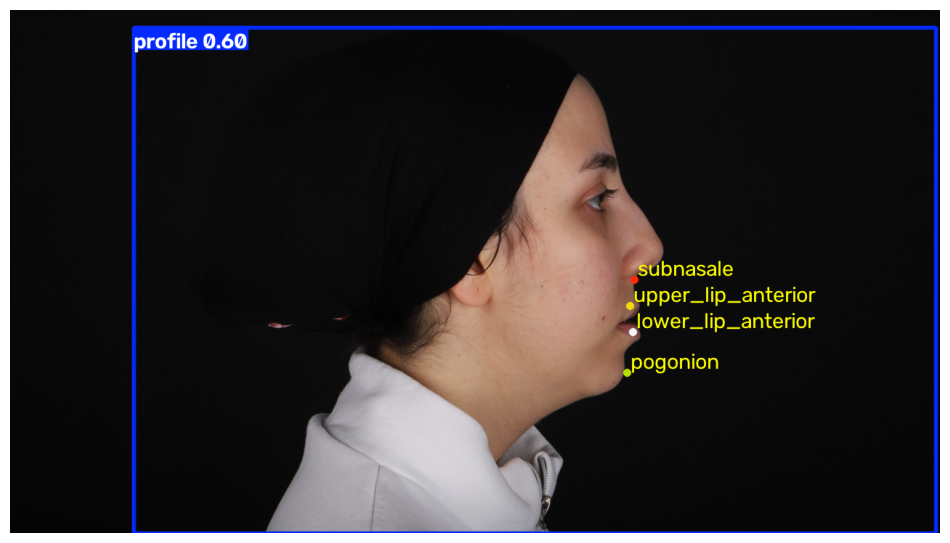

In [41]:
result = results[0]
image=result.plot()

points = result.keypoints.xy[0].cpu().numpy()
confidences = result.keypoints.conf[0].cpu().numpy()

names = [
    "subnasale",
    "upper_lip_anterior",
    "lower_lip_anterior",
    "pogonion",
]

for name, (x, y), confidence in zip(names, points, confidences):
    if confidence < 0.25:
        continue

    cv2.putText(
        image,
        name,
        (int(x) + 5, int(y) - 5),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 255, 255),
        1,
        cv2.LINE_AA,
    )

plt.figure(figsize=(12, 8))
plt.imshow(image[..., ::-1])
plt.axis("off")
plt.show()